In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
from sklearn.datasets import make_blobs

In [76]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [77]:
X

array([[ 9.51679095, -4.95464633],
       [ 8.89236666,  6.64625593],
       [-0.17315854, -0.50499298],
       ...,
       [ 8.73459466,  6.13985755],
       [-1.85089723, -2.29588935],
       [ 8.82579062, -6.2198879 ]], shape=(1000, 2))

In [78]:
y

array([2, 0, 1, 2, 1, 0, 2, 0, 2, 0, 2, 1, 0, 2, 1, 2, 2, 0, 1, 2, 2, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 2, 2, 2, 2, 1, 2, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 2, 0, 1, 1, 1, 0, 1, 1, 2, 2, 0, 2, 0, 1, 0, 2, 1, 2, 0, 0,
       0, 0, 0, 0, 1, 1, 2, 1, 2, 2, 1, 1, 1, 0, 0, 2, 2, 2, 2, 0, 2, 0,
       0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 0, 0, 1, 2, 1, 0, 1,
       0, 0, 2, 0, 0, 1, 2, 1, 0, 1, 1, 0, 0, 1, 2, 2, 0, 2, 1, 2, 2, 2,
       0, 0, 2, 1, 1, 2, 1, 1, 1, 2, 1, 0, 0, 1, 2, 2, 0, 2, 1, 1, 1, 2,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 2, 0, 2, 2, 0, 0, 0, 2, 0, 0, 1,
       1, 2, 2, 1, 1, 2, 1, 1, 0, 1, 2, 2, 1, 1, 0, 0, 0, 0, 2, 1, 1, 1,
       0, 2, 1, 2, 1, 1, 0, 2, 1, 0, 1, 2, 0, 1, 0, 1, 2, 2, 0, 2, 0, 1,
       0, 1, 0, 2, 2, 2, 1, 2, 0, 1, 2, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 1,
       0, 1, 0, 2, 2, 1, 0, 1, 1, 0, 1, 2, 2, 0, 2, 1, 1, 1, 0, 0, 2, 1,
       2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 0, 2, 2, 1, 0, 0, 1, 0, 2, 2, 1, 0,
       2, 0, 1, 2, 0, 2, 1, 2, 0, 1, 1, 1, 2, 2, 0,

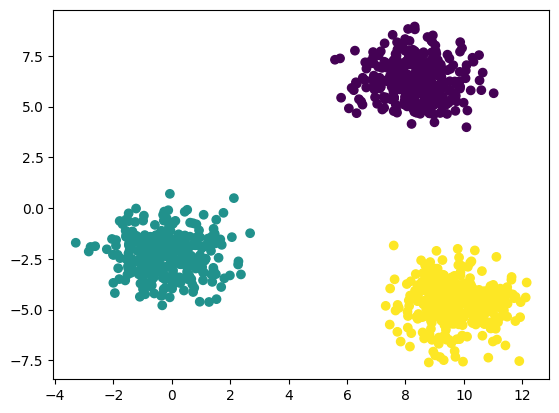

In [79]:
plt.scatter(x=X[:,0],y=X[:,1],c=y)

In [80]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [81]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [82]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [83]:
from sklearn.cluster import KMeans


In [84]:
##To slect k value we use elbow method
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [85]:
wcss

[1339.9999999999989,
 655.5162225537721,
 58.45091567284086,
 51.67746030706744,
 45.58820771639486,
 37.98337764188859,
 34.63153859000564,
 29.22004847915151,
 25.825606762329343,
 25.086373543378095]

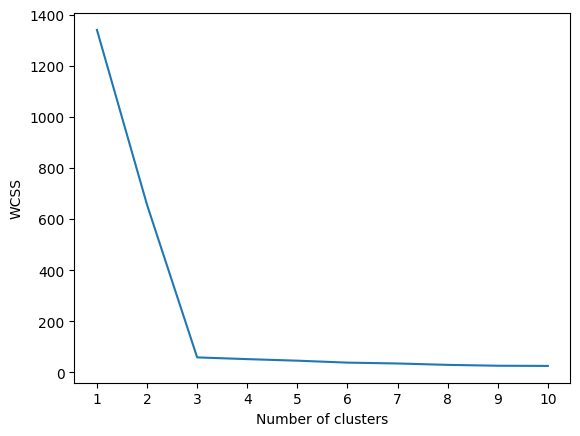

In [86]:
## Plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [87]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [88]:
kmeans.fit_predict(X_train_scaled)

array([1, 2, 1, 0, 0, 2, 2, 0, 1, 2, 1, 1, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2,
       0, 2, 0, 0, 2, 0, 1, 2, 1, 0, 1, 2, 0, 2, 1, 2, 0, 1, 2, 2, 1, 2,
       0, 1, 0, 1, 1, 2, 2, 1, 0, 0, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 2, 2,
       0, 1, 0, 2, 2, 2, 1, 2, 1, 0, 2, 1, 2, 2, 1, 0, 2, 0, 0, 1, 2, 2,
       0, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 2, 2, 1, 2, 2, 0,
       0, 1, 2, 2, 0, 1, 1, 1, 0, 0, 2, 2, 0, 2, 2, 0, 2, 0, 1, 2, 0, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 2, 0, 0, 2, 0, 0, 1, 1, 0, 1, 0, 2, 1, 1,
       2, 2, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 2, 2, 1, 0, 1, 0, 0, 2,
       1, 0, 1, 1, 1, 2, 2, 0, 1, 0, 2, 1, 1, 2, 0, 2, 1, 1, 0, 1, 1, 1,
       0, 2, 1, 2, 2, 1, 2, 2, 0, 0, 0, 1, 1, 2, 0, 2, 1, 2, 2, 0, 1, 2,
       0, 1, 1, 0, 2, 2, 2, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 2, 2, 0, 0, 2, 1, 2, 1, 1, 2, 1, 0, 2, 2, 1,
       2, 1, 2, 2, 1, 0, 2, 0, 2, 2, 1, 0, 2, 1, 0, 2, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 2, 2, 2, 2, 2, 0, 0, 1, 2, 1, 1, 0,

In [89]:
y_pred=kmeans.predict(X_test_scaled)

In [90]:
y_pred

array([0, 2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 1, 2, 0, 2, 2, 2,
       0, 1, 2, 2, 0, 0, 2, 0, 2, 1, 1, 2, 0, 2, 0, 0, 2, 1, 1, 2, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 2, 0, 2, 2, 1, 0, 1, 1, 1, 0, 1, 0, 2, 1,
       2, 1, 1, 0, 1, 0, 1, 2, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 2, 0, 1, 2,
       0, 2, 0, 0, 1, 2, 1, 2, 2, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 2, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 2, 0, 2, 1, 2, 2, 2, 0, 1, 2, 2, 2, 0, 1, 0, 1,
       1, 2, 2, 0, 2, 0, 1, 1, 2, 0, 2, 2, 0, 0, 2, 1, 1, 2, 2, 0, 2, 2,
       0, 1, 0, 1, 0, 2, 0, 2, 1, 0, 2, 1, 0, 1, 1, 2, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 2, 0, 1, 0, 0, 1, 1, 0, 2, 0, 1, 2, 1, 0, 2, 1, 2, 0,
       0, 2, 1, 1, 0, 1, 1, 2, 2, 1, 1, 1, 1, 2, 0, 0, 2, 0, 2, 1, 0, 2,
       1, 1, 1, 1, 2, 1, 0, 0, 0, 2, 2, 2, 0, 0, 1, 1, 1, 2, 2, 2, 2, 0,
       0, 0, 0, 0, 1, 2, 2, 2, 2, 1, 2, 2, 1, 0, 0, 0, 2, 0, 0, 2, 1, 1,
       1, 0, 0, 0, 2, 1, 1, 0, 2, 2, 1, 2, 2, 2, 1,

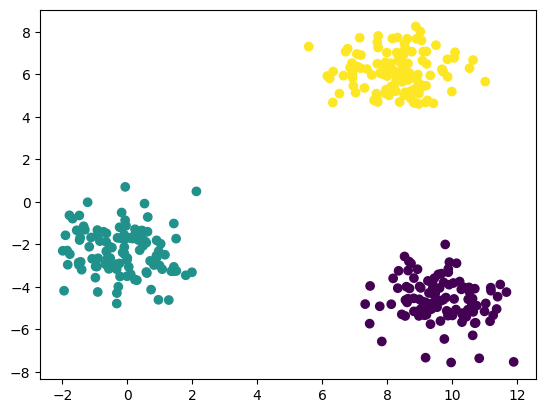

In [91]:
plt.scatter(x=X_test[:,0],y=X_test[:,1],c=y_pred)

## Validating the k value
1- Kneelocater

2- Silhoutee scoring

In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator
knee=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [ ]:
knee.elbow

np.int64(3)

In [ ]:
## Silhoutte Scoring
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_coeff = []
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coeff.append(score)

In [ ]:
silhouette_coeff

[np.float64(0.6328254392413445),
 np.float64(0.622035210224647),
 np.float64(0.5606722989366894),
 np.float64(0.4924077093591801),
 np.float64(0.48308695663068474),
 np.float64(0.4781125460182493),
 np.float64(0.4697617114959833),
 np.float64(0.4412482808048052),
 np.float64(0.4432783329480984)]

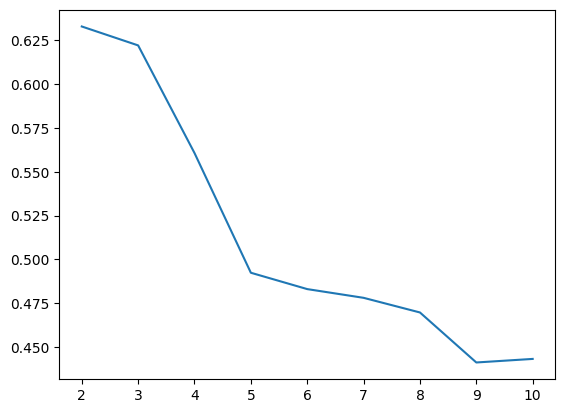

In [ ]:
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))
plt.show()